# 🔍 Driver Inattention — 결과 분석 노트북

학습 노트북에서 저장한 모델/캐시를 로드해서 시각화/분석.

### 분석 내용
- 3-Model 비교표 재구성
- ROC Curve (per-class, OvR)
- **Grad-CAM** — EfficientNet-B0 (어디를 봤는지)
- **Grad-CAM** — ViT-Small (Transformer는 어떻게 다른가)
- 정성적 실패 분석 (cost 큰 오분류 + Grad-CAM)

---
## 0. 환경 설정

In [3]:
# ── 패키지 설치 ──
import subprocess, sys
for pkg, mod in [('grad-cam','pytorch_grad_cam'),
                  ('timm','timm'),
                  ('scikit-image','skimage')]:
    try: __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

# ── 공통 import ──
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter
from pytorch_grad_cam import GradCAM

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import efficientnet_b0
import timm
import joblib
from sklearn.metrics import (confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score, accuracy_score,
    f1_score, precision_score, recall_score)

# ── 한글 폰트 (Colab) ──
subprocess.run(['apt','-qq','install','-y','fonts-nanum'], check=False, capture_output=True)
import matplotlib.font_manager as fm
fp = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(fp):
    fm.fontManager.addfont(fp); plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Device: {device}')

✓ Device: cuda


---
## 1. Drive 마운트 & 캐시 로드

학습 노트북이 저장해둔 5개 파일을 불러옵니다:
- `effnet_b0_final.pth`, `vit_small_final.pth`, `hog_svm.joblib`  (모델 가중치)
- `test_results.npz`  (test 추론 결과 — 재추론 불필요)
- `meta.json`  (class list, hyperparams)
- `df_test.parquet`  (이미지 경로 + bbox)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── 본인 경로에 맞게 수정 ──
SAVE_DIR = '/content/drive/MyDrive/Machine_Learning_Term_Project/results'
DATA_DIR = '/content/drive/MyDrive/Machine_Learning_Term_Project/Driver_inattention_data'

# 데이터셋 로컬 복사 (Grad-CAM에서 원본 이미지 필요)
import shutil
LOCAL_DATA = '/content/dmd'
if not os.path.exists(LOCAL_DATA):
    print('Drive → 로컬 복사 중... (~1-2분)')
    shutil.copytree(DATA_DIR, LOCAL_DATA)
    print('✓ 복사 완료')
else:
    print('✓ 이미 복사됨')

# ── 메타데이터 ──
with open(os.path.join(SAVE_DIR, 'meta.json')) as f:
    meta = json.load(f)
CLASS_LIST  = meta['class_list']
NUM_CLASSES = len(CLASS_LIST)
RISK_LEVEL  = {k: tuple(v) for k, v in meta['risk_level'].items()}
RISK_W      = meta['risk_w']
IMG_SIZE    = meta['img_size']
def get_risk(c): return RISK_LEVEL.get(c, ('Medium', '#f39c12'))

# ── Test 추론 결과 ──
R = np.load(os.path.join(SAVE_DIR, 'test_results.npz'))
results = {
    'HOG+SVM (LinearSVC)': dict(preds=R['preds_svm'], probs=R['probs_svm'], labels=R['labels_svm']),
    'EfficientNet-B0':     dict(preds=R['preds_eff'], probs=R['probs_eff'], labels=R['labels_eff']),
    'ViT-Small':           dict(preds=R['preds_vit'], probs=R['probs_vit'], labels=R['labels_vit']),
}

# ── df_test (Grad-CAM 시각화용) ──
df_test = pd.read_parquet(os.path.join(SAVE_DIR, 'df_test.parquet'))
# 학습 시 저장된 경로(/content/dmd/...)와 동일하면 그대로 사용
# 다른 경로면 아래 한 줄로 보정
df_test['path'] = df_test['path'].apply(
    lambda p: p.replace(DATA_DIR, LOCAL_DATA) if p.startswith(DATA_DIR) else p
)

print(f'✓ Meta: {list(meta.keys())}')
print(f'✓ 클래스: {CLASS_LIST}')
print(f'✓ Test 샘플: {len(df_test)}')
print(f'✓ 결과 모델: {list(results.keys())}')

Mounted at /content/drive
Drive → 로컬 복사 중... (~1-2분)
✓ 복사 완료
✓ Meta: ['class_list', 'class_to_idx', 'risk_level', 'risk_w', 'img_size', 'batch_size', 'hog_params', 'hog_size', 'best_svm_C', 'splits']
✓ 클래스: ['DangerousDriving', 'Distracted', 'Drinking', 'SafeDriving', 'SleepyDriving', 'Yawn']
✓ Test 샘플: 985
✓ 결과 모델: ['HOG+SVM (LinearSVC)', 'EfficientNet-B0', 'ViT-Small']


---
## 2. 모델 가중치 재로드

학습 노트북과 동일한 빌더 함수로 모델 골격을 만들고, `.pth`를 로드합니다.

In [ ]:
def build_efficientnet(num_classes):
    m = efficientnet_b0(weights=None)   # 가중치는 .pth로 따로 로드
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_f, 256), nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes),
    )
    return m.to(device)

def build_vit_small(num_classes):
    m = timm.create_model('vit_small_patch16_224', pretrained=False)
    in_f = m.head.in_features
    m.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_f, num_classes))
    return m.to(device)

# EfficientNet-B0
effnet = build_efficientnet(NUM_CLASSES)
effnet.load_state_dict(torch.load(
    os.path.join(SAVE_DIR, 'effnet_b0_final.pth'), map_location=device))
effnet.eval()

# ViT-Small
vit = build_vit_small(NUM_CLASSES)
vit.load_state_dict(torch.load(
    os.path.join(SAVE_DIR, 'vit_small_final.pth'), map_location=device))
vit.eval()

# HOG+SVM 번들
svm_bundle = joblib.load(os.path.join(SAVE_DIR, 'hog_svm.joblib'))
print(f'✓ EfficientNet-B0 params: {sum(p.numel() for p in effnet.parameters()):,}')
print(f'✓ ViT-Small       params: {sum(p.numel() for p in vit.parameters()):,}')
print(f'✓ SVM 번들 keys   : {list(svm_bundle.keys())}')

✓ EfficientNet-B0 params: 4,337,026
✓ ViT-Small       params: 21,667,974
✓ SVM 번들 keys   : ['svm', 'scaler', 'best_C', 'hog_params', 'hog_size']


---
## 3. 3-Model 비교 + ROC Curve

                     Accuracy  Precision (m)  Recall (m)  F1 (macro)  F1 (weighted)  ROC-AUC (OvR)
Model                                                                                             
HOG+SVM (LinearSVC)    0.9117         0.8555      0.8858      0.8690         0.9122         0.9814
EfficientNet-B0        0.9675         0.9460      0.9762      0.9603         0.9677         0.9972
ViT-Small              0.9756         0.9613      0.9827      0.9716         0.9757         0.9988


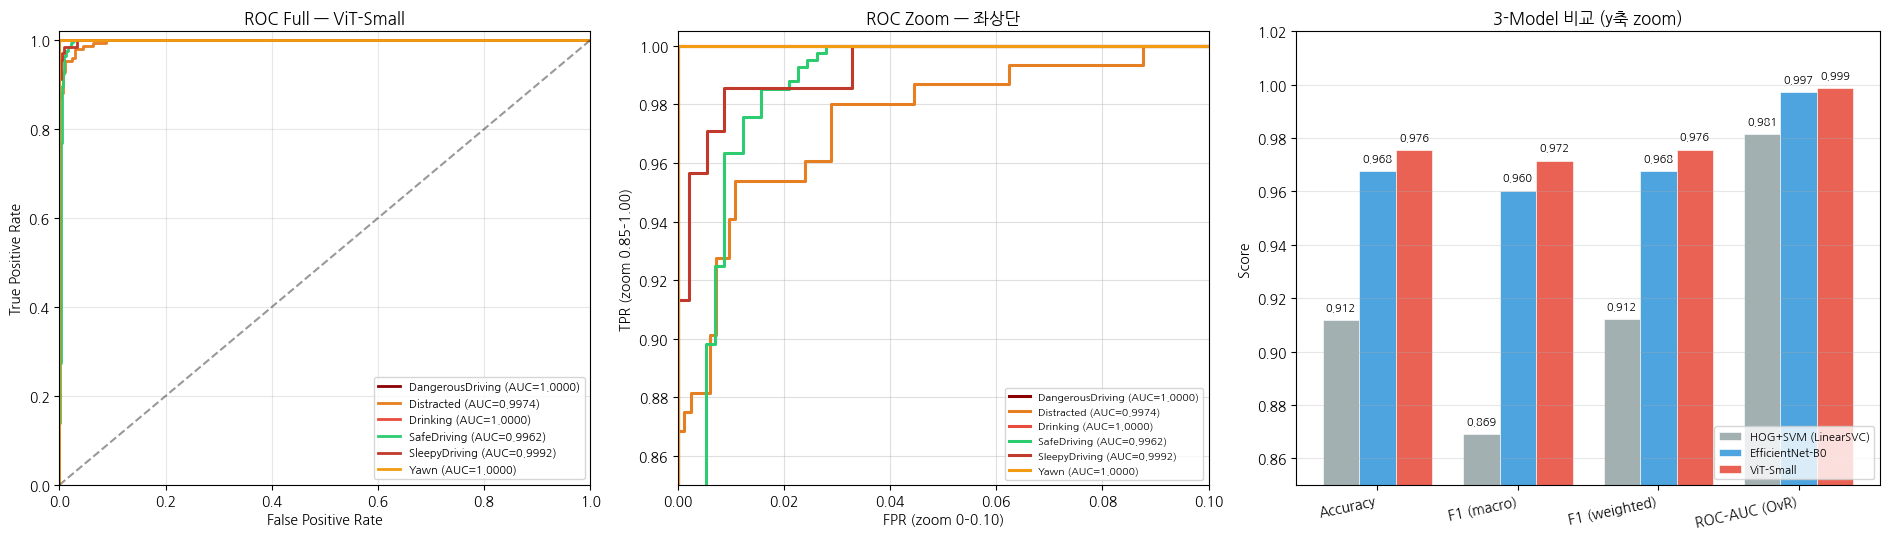

In [ ]:
# ── 비교표 재구성 ──
rows = []
for name, r in results.items():
    rows.append({
        'Model': name,
        'Accuracy':       accuracy_score(r['labels'], r['preds']),
        'Precision (m)':  precision_score(r['labels'], r['preds'], average='macro', zero_division=0),
        'Recall (m)':     recall_score(r['labels'], r['preds'], average='macro', zero_division=0),
        'F1 (macro)':     f1_score(r['labels'], r['preds'], average='macro'),
        'F1 (weighted)':  f1_score(r['labels'], r['preds'], average='weighted'),
        'ROC-AUC (OvR)':  roc_auc_score(r['labels'], r['probs'], multi_class='ovr', average='macro'),
    })
cmp_df = pd.DataFrame(rows).set_index('Model')
print(cmp_df.to_string(float_format='{:.4f}'.format))

# ── ROC + 비교 (가독성 개선: zoom view 추가, y축 조정) ──
best_name = cmp_df['F1 (macro)'].idxmax()
r = results[best_name]
y_true = np.array(r['labels']); y_score = r['probs']

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5),
                          gridspec_kw={'width_ratios': [1, 1, 1.1]})

# (1) ROC Full view — 전체 모양 확인
for i, cls in enumerate(CLASS_LIST):
    fpr, tpr, _ = roc_curve((y_true==i).astype(int), y_score[:, i])
    axes[0].plot(fpr, tpr, lw=2, color=get_risk(cls)[1],
                 label=f'{cls} (AUC={auc(fpr,tpr):.4f})')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.02)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Full — {best_name}', fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right'); axes[0].grid(alpha=0.3)

# (2) ROC Zoom — 좌상단 확대
for i, cls in enumerate(CLASS_LIST):
    fpr, tpr, _ = roc_curve((y_true==i).astype(int), y_score[:, i])
    axes[1].plot(fpr, tpr, lw=2.2, color=get_risk(cls)[1],
                 label=f'{cls} (AUC={auc(fpr,tpr):.4f})')
axes[1].plot([0,0.1],[0,0.1], 'k--', alpha=0.4)
axes[1].set_xlim(0, 0.10); axes[1].set_ylim(0.85, 1.005)
axes[1].set_xlabel('FPR (zoom 0–0.10)'); axes[1].set_ylabel('TPR (zoom 0.85–1.00)')
axes[1].set_title('ROC Zoom — 좌상단', fontweight='bold')
axes[1].legend(fontsize=7.5, loc='lower right'); axes[1].grid(alpha=0.4)

# (3) 모델별 metric 비교
colors_m = {'HOG+SVM (LinearSVC)': '#95a5a6',
            'EfficientNet-B0': '#3498db',
            'ViT-Small': '#e74c3c'}
metric_names = ['Accuracy', 'F1 (macro)', 'F1 (weighted)', 'ROC-AUC (OvR)']
x = np.arange(len(metric_names)); w = 0.26
for i, name in enumerate(cmp_df.index):
    vals = cmp_df.loc[name, metric_names].values
    bars = axes[2].bar(x+(i-1)*w, vals, w,
                        label=name, color=colors_m[name], alpha=0.88,
                        edgecolor='white', linewidth=0.5)
    for b, v in zip(bars, vals):
        axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=8)
axes[2].set_xticks(x); axes[2].set_xticklabels(metric_names, rotation=12, ha='right')
axes[2].set_ylim(0.85, 1.02)            # ← y축 zoom
axes[2].set_ylabel('Score')
axes[2].set_title('3-Model 비교 (y축 zoom)', fontweight='bold')
axes[2].legend(loc='lower right', fontsize=8)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('analysis_roc_compare.png', dpi=130, bbox_inches='tight')
plt.show()

[ViT-Small] 신뢰도 통계
  평균 신뢰도 (전체): 0.6865
  평균 신뢰도 (정답): 0.6881
  평균 신뢰도 (오답): 0.6220
  신뢰도 > 0.9 비율 : 10.7%


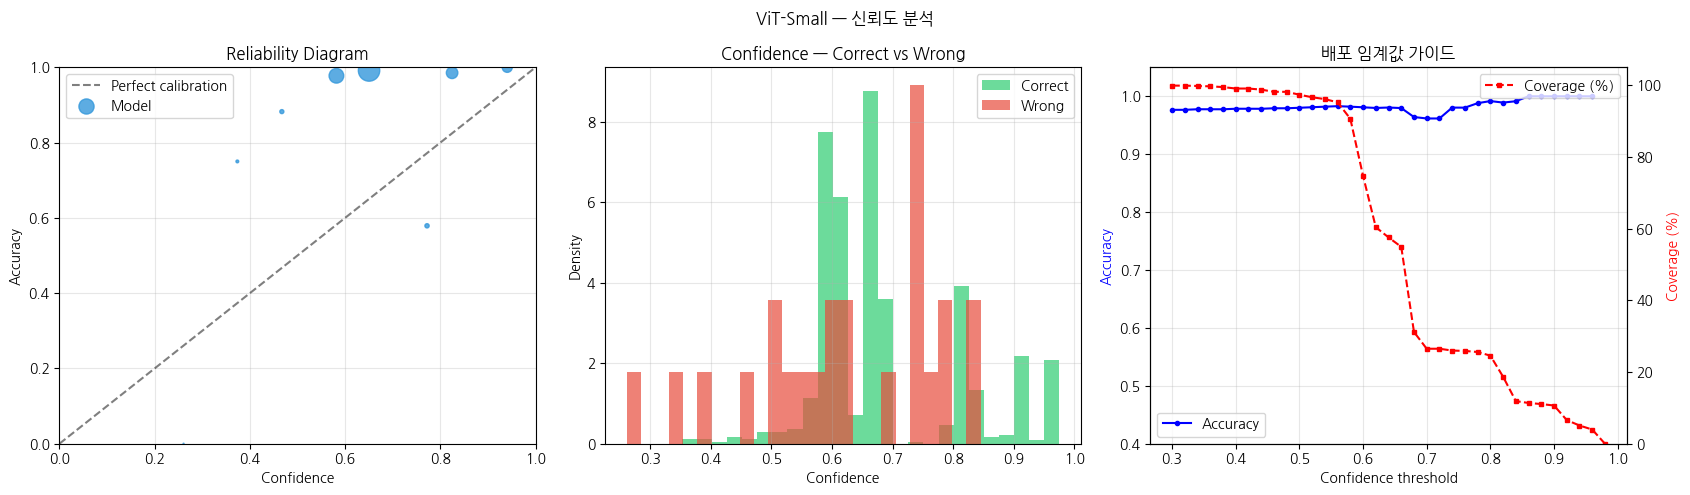


📊 Threshold별 Coverage & Accuracy (보고서 Table Z용)
 Threshold   Coverage   Accuracy
--------------------------------
      0.50      97.4%     0.9802
      0.70      26.5%     0.9617
      0.80      24.6%     0.9917
      0.90      10.7%     1.0000
      0.95       5.1%     1.0000
      0.99       0.0%        nan


In [ ]:
# ── 신뢰도 보정 분석 ──
probs  = results[best_name]['probs']
preds  = results[best_name]['preds']
labels = np.array(results[best_name]['labels'])
max_conf   = probs.max(axis=1)
is_correct = (preds == labels).astype(int)

print(f'[{best_name}] 신뢰도 통계')
print(f'  평균 신뢰도 (전체): {max_conf.mean():.4f}')
print(f'  평균 신뢰도 (정답): {max_conf[is_correct==1].mean():.4f}')
print(f'  평균 신뢰도 (오답): {max_conf[is_correct==0].mean():.4f}')
print(f'  신뢰도 > 0.9 비율 : {(max_conf>0.9).mean()*100:.1f}%')

# Calibration bins
bins = np.linspace(0, 1, 11)
bin_accs, bin_confs, bin_cnts = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (max_conf>=lo) & ((max_conf<hi) if hi<1 else (max_conf<=hi))
    if m.sum() > 0:
        bin_accs.append(is_correct[m].mean())
        bin_confs.append(max_conf[m].mean())
        bin_cnts.append(int(m.sum()))
    else:
        bin_accs.append(np.nan); bin_confs.append((lo+hi)/2); bin_cnts.append(0)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
valid = ~np.isnan(bin_accs)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.5, label='Perfect calibration')
axes[0].scatter(np.array(bin_confs)[valid], np.array(bin_accs)[valid],
                s=np.array(bin_cnts)[valid]*0.5, c='#3498db', alpha=0.8, label='Model')
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Reliability Diagram', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(max_conf[is_correct==1], bins=25, alpha=0.7, color='#2ecc71', label='Correct', density=True)
axes[1].hist(max_conf[is_correct==0], bins=25, alpha=0.7, color='#e74c3c', label='Wrong',   density=True)
axes[1].set_xlabel('Confidence'); axes[1].set_ylabel('Density')
axes[1].set_title('Confidence — Correct vs Wrong', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

thrs = np.arange(0.3, 1.0, 0.02)
covs, accs_at_t = [], []
for t in thrs:
    m = max_conf >= t
    covs.append(m.mean()*100)
    accs_at_t.append(is_correct[m].mean() if m.sum()>0 else np.nan)
ax2 = axes[2].twinx()
axes[2].plot(thrs, accs_at_t, 'b-o', ms=3, label='Accuracy')
ax2.plot(thrs, covs, 'r--s', ms=3, label='Coverage (%)')
axes[2].set_xlabel('Confidence threshold'); axes[2].set_ylabel('Accuracy', color='blue')
ax2.set_ylabel('Coverage (%)', color='red')
axes[2].set_title('배포 임계값 가이드', fontweight='bold')
axes[2].set_ylim(0.4, 1.05); ax2.set_ylim(0, 105)
axes[2].grid(alpha=0.3)
axes[2].legend(loc='lower left'); ax2.legend(loc='upper right')

plt.suptitle(f'{best_name} — 신뢰도 분석', fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_confidence.png', dpi=130, bbox_inches='tight')
plt.show()

# 보고서 Table Z용 임계값 수치 출력
print('\n📊 Threshold별 Coverage & Accuracy (보고서 Table Z용)')
print(f'{"Threshold":>10} {"Coverage":>10} {"Accuracy":>10}')
print('-'*32)
for t in [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]:
    m = max_conf >= t
    cov = m.mean()*100
    acc = is_correct[m].mean() if m.sum()>0 else float('nan')
    print(f'{t:>10.2f} {cov:>9.1f}% {acc:>10.4f}')

---
## 4. Grad-CAM — EfficientNet-B0

CNN이 어떤 영역을 보고 분류했는지 heatmap으로 확인.
- 대상 layer: `model.features[-1]` (마지막 conv block)
- 클래스별 정답 케이스 1장씩 → 모델이 클래스를 어떻게 인식했는지 직관적으로 확인

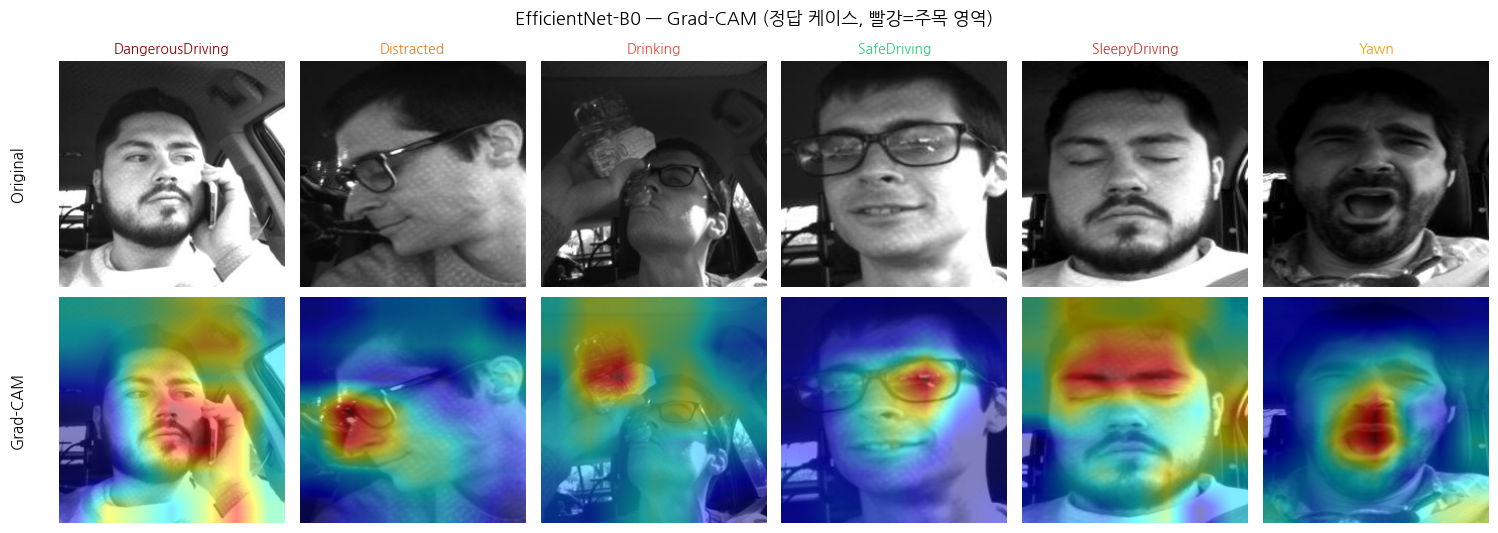

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 학습 노트북과 동일한 eval transform
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

def load_crop(row, pad_ratio=0.2):
    """학습 시 사용한 것과 동일한 bbox+padding 크롭"""
    img = Image.open(row['path']).convert('RGB')
    W, H = img.size
    bw = row['x2']-row['x1']; bh = row['y2']-row['y1']
    px = int(bw*pad_ratio); py = int(bh*pad_ratio)
    x1 = max(0,row['x1']-px); y1 = max(0,row['y1']-py)
    x2 = min(W,row['x2']+px); y2 = min(H,row['y2']+py)
    return img.crop((x1,y1,x2,y2)).resize((IMG_SIZE, IMG_SIZE))

# 클래스별 정답 케이스 1장씩 선택
eff_labels = results['EfficientNet-B0']['labels']
eff_preds  = results['EfficientNet-B0']['preds']
correct = np.where(eff_preds == eff_labels)[0]
samples = []
for c in range(NUM_CLASSES):
    cls_idxs = [i for i in correct if eff_labels[i]==c]
    if cls_idxs: samples.append((c, cls_idxs[0]))

# Grad-CAM 객체
cam_eff = GradCAM(model=effnet, target_layers=[effnet.features[-1]])

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(15, 5.5))
for col, (c, idx) in enumerate(samples):
    row = df_test.iloc[idx]
    crop = load_crop(row)
    arr  = np.array(crop) / 255.0
    inp  = eval_tf(crop).unsqueeze(0).to(device)

    grayscale_cam = cam_eff(input_tensor=inp,
                             targets=[ClassifierOutputTarget(c)])[0]
    visual = show_cam_on_image(arr, grayscale_cam, use_rgb=True)

    axes[0, col].imshow(arr); axes[0, col].axis('off')
    axes[0, col].set_title(CLASS_LIST[c], fontsize=10, fontweight='bold',
                            color=get_risk(CLASS_LIST[c])[1])
    axes[1, col].imshow(visual); axes[1, col].axis('off')

# y축 라벨 (첫 열에만)
axes[0, 0].text(-0.15, 0.5, 'Original', transform=axes[0,0].transAxes,
                rotation=90, va='center', ha='right', fontsize=11, fontweight='bold')
axes[1, 0].text(-0.15, 0.5, 'Grad-CAM', transform=axes[1,0].transAxes,
                rotation=90, va='center', ha='right', fontsize=11, fontweight='bold')
plt.suptitle('EfficientNet-B0 — Grad-CAM (정답 케이스, 빨강=주목 영역)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_gradcam_efficientnet.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 5. Grad-CAM — ViT-Small

ViT는 patch token이라 reshape transform 필요.
- 224 입력 / patch 16 → **14×14 patch grid**
- 대상 layer: 마지막 Transformer block의 `norm1`
- CNN과 다른 attention 패턴을 보일 가능성

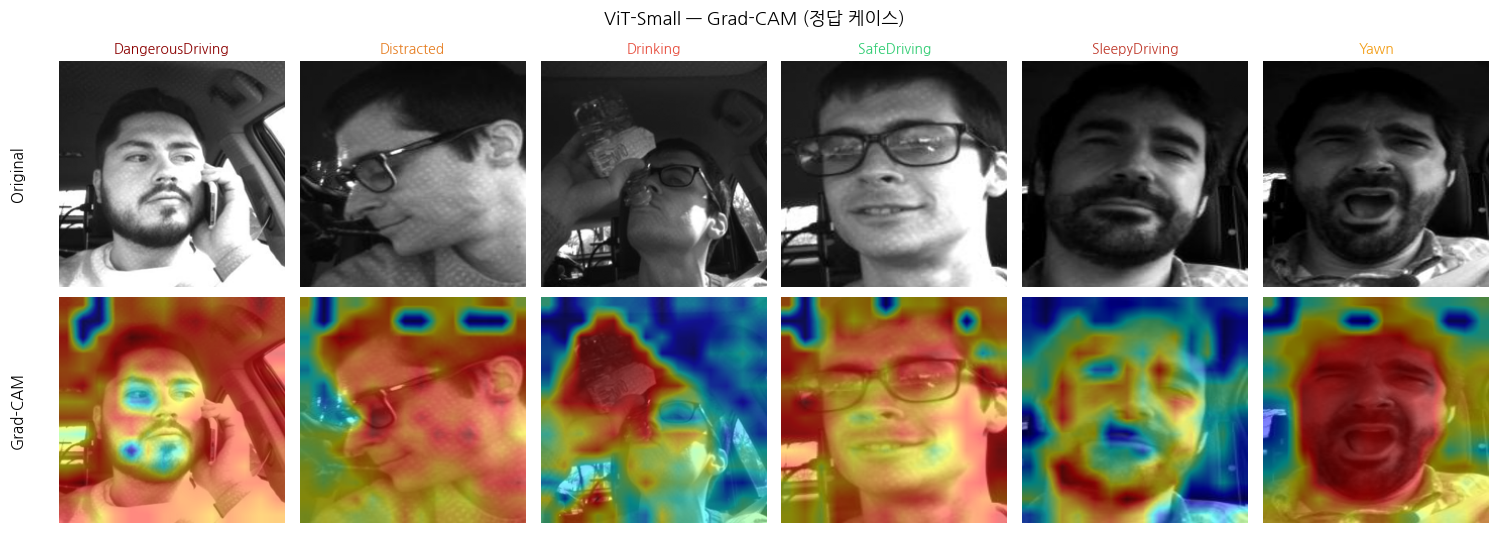

In [ ]:
def reshape_vit(tensor, h=14, w=14):
    """ViT 출력: [B, 197, C] → [B, C, 14, 14]
    - 첫 token (CLS) 제거 → 196개 patch token
    - 14×14 grid로 reshape → conv-like heatmap"""
    result = tensor[:, 1:, :].reshape(tensor.size(0), h, w, tensor.size(2))
    return result.transpose(2, 3).transpose(1, 2)

cam_vit = GradCAM(model=vit,
                   target_layers=[vit.blocks[-1].norm1],
                   reshape_transform=reshape_vit)

vit_labels = results['ViT-Small']['labels']
vit_preds  = results['ViT-Small']['preds']
correct_v = np.where(vit_preds == vit_labels)[0]
samples_v = []
for c in range(NUM_CLASSES):
    cls_idxs = [i for i in correct_v if vit_labels[i]==c]
    if cls_idxs: samples_v.append((c, cls_idxs[0]))

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(15, 5.5))
for col, (c, idx) in enumerate(samples_v):
    row = df_test.iloc[idx]
    crop = load_crop(row); arr = np.array(crop)/255.0
    inp  = eval_tf(crop).unsqueeze(0).to(device)

    grayscale_cam = cam_vit(input_tensor=inp,
                             targets=[ClassifierOutputTarget(c)])[0]
    visual = show_cam_on_image(arr, grayscale_cam, use_rgb=True)

    axes[0, col].imshow(arr); axes[0, col].axis('off')
    axes[0, col].set_title(CLASS_LIST[c], fontsize=10, fontweight='bold',
                            color=get_risk(CLASS_LIST[c])[1])
    axes[1, col].imshow(visual); axes[1, col].axis('off')

axes[0, 0].text(-0.15, 0.5, 'Original', transform=axes[0,0].transAxes,
                rotation=90, va='center', ha='right', fontsize=11, fontweight='bold')
axes[1, 0].text(-0.15, 0.5, 'Grad-CAM', transform=axes[1,0].transAxes,
                rotation=90, va='center', ha='right', fontsize=11, fontweight='bold')
plt.suptitle('ViT-Small — Grad-CAM (정답 케이스)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_gradcam_vit.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 6. 정성적 실패 분석

가장 비용이 큰 오분류 Top 6을 Grad-CAM으로 분석.
**모델이 잘못된 영역을 보고 있나? 아니면 같은 영역을 봐도 클래스를 헷갈렸나?**

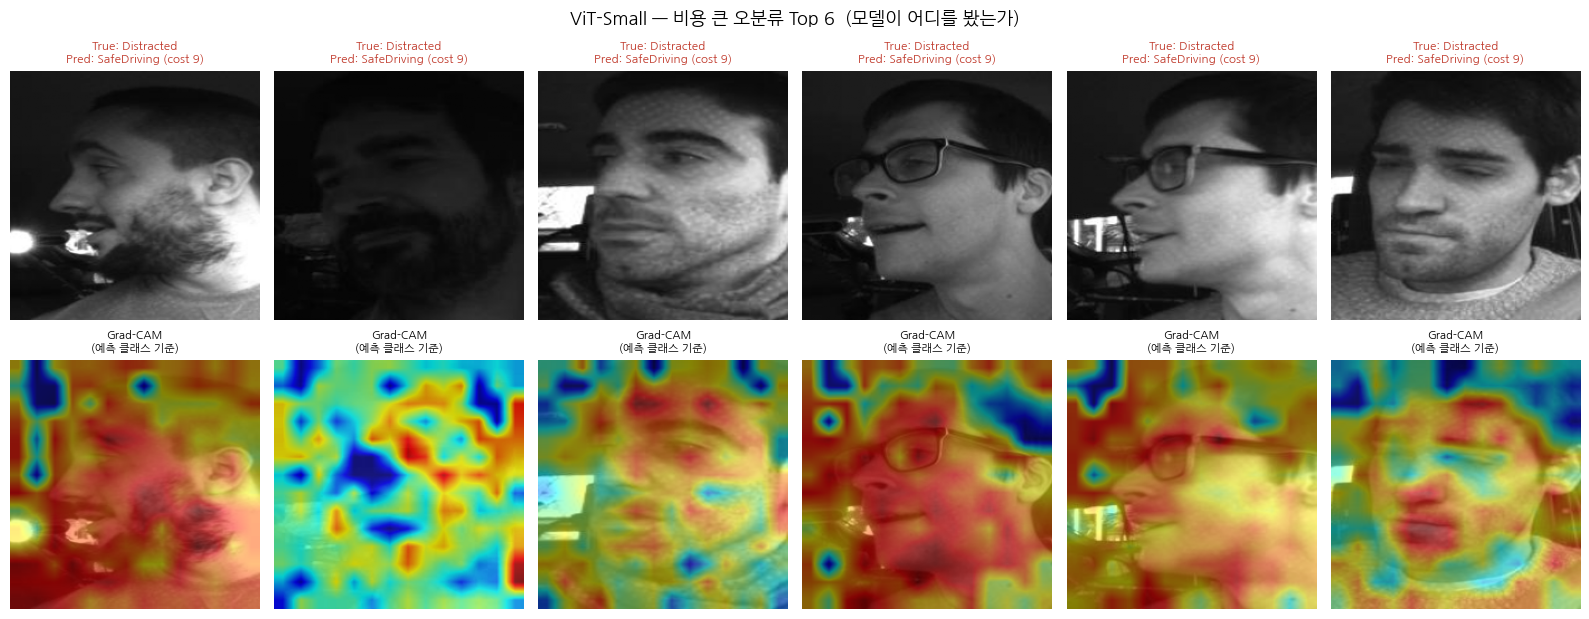


자주 혼동되는 쌍 (Top 8):
True                   → Predicted                Count    Cost
----------------------------------------------------------------------
SafeDriving            → Distracted                   8       1
Distracted             → SafeDriving                  6       9
SafeDriving            → SleepyDriving                4       1
Distracted             → SleepyDriving                2       1
SafeDriving            → Drinking                     2       1
SleepyDriving          → Distracted                   1       4
SafeDriving            → DangerousDriving             1       1


In [ ]:
# ── Cost matrix 재구성 ──
cost_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))
for i, ci in enumerate(CLASS_LIST):
    for j, cj in enumerate(CLASS_LIST):
        if i != j:
            ri, rj = RISK_W[get_risk(ci)[0]], RISK_W[get_risk(cj)[0]]
            cost_matrix[i, j] = max(1, ri - rj + 1) ** 2

# Best model 기준 오분류
r = results[best_name]
labels = np.array(r['labels']); preds = r['preds']
wrong_list = [(i, int(labels[i]), int(preds[i]),
                float(cost_matrix[labels[i], preds[i]]))
              for i in range(len(labels)) if labels[i] != preds[i]]
worst = sorted(wrong_list, key=lambda x: -x[3])[:6]

# best_name에 맞는 cam 선택
target_cam = cam_eff if best_name == 'EfficientNet-B0' else (
              cam_vit if best_name == 'ViT-Small' else None)

if target_cam is None:
    print(f'⚠️  {best_name}은 Grad-CAM 미지원 — 이미지만 표시')
    fig, axes = plt.subplots(1, 6, figsize=(16, 4))
    for col, (idx, t, p, c) in enumerate(worst):
        crop = load_crop(df_test.iloc[idx])
        axes[col].imshow(np.array(crop)/255.0); axes[col].axis('off')
        axes[col].set_title(f'True: {CLASS_LIST[t]}\nPred: {CLASS_LIST[p]}\nCost={c:.0f}',
                             fontsize=8.5, color='#c0392b')
else:
    fig, axes = plt.subplots(2, 6, figsize=(16, 6.5))
    for col, (idx, t, p, c) in enumerate(worst):
        row = df_test.iloc[idx]
        crop = load_crop(row); arr = np.array(crop)/255.0
        inp = eval_tf(crop).unsqueeze(0).to(device)

        # 예측 클래스 기준 heatmap (모델이 왜 그렇게 예측했나)
        grayscale_cam = target_cam(input_tensor=inp,
                                    targets=[ClassifierOutputTarget(p)])[0]
        visual = show_cam_on_image(arr, grayscale_cam, use_rgb=True)

        axes[0, col].imshow(arr); axes[0, col].axis('off')
        axes[0, col].set_title(f'True: {CLASS_LIST[t]}\nPred: {CLASS_LIST[p]} (cost {c:.0f})',
                                fontsize=8.5, color='#c0392b')
        axes[1, col].imshow(visual); axes[1, col].axis('off')
        axes[1, col].set_title('Grad-CAM\n(예측 클래스 기준)', fontsize=8)
plt.suptitle(f'{best_name} — 비용 큰 오분류 Top 6  (모델이 어디를 봤는가)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_failure_gradcam.png', dpi=130, bbox_inches='tight')
plt.show()

# 자주 혼동되는 쌍 (Top 8)
print('\n자주 혼동되는 쌍 (Top 8):')
print(f'{"True":<22} → {"Predicted":<22}  {"Count":>6}  {"Cost":>6}')
print('-'*70)
wrong_pairs = [(t,p) for (_,t,p,_) in wrong_list]
for (t, p), cnt in Counter(wrong_pairs).most_common(8):
    print(f'{CLASS_LIST[t]:<22} → {CLASS_LIST[p]:<22}  {cnt:>6}  {cost_matrix[t,p]:>6.0f}')

---
## 7. 분석 결과 저장

생성된 분석 그림을 Drive에 백업.

In [ ]:
for fname in ['analysis_roc_compare.png',
              'analysis_gradcam_efficientnet.png',
              'analysis_gradcam_vit.png',
              'analysis_failure_gradcam.png']:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(SAVE_DIR, fname))
        print(f'✓ {fname}')
print(f'\n저장 위치: {SAVE_DIR}')

✓ analysis_roc_compare.png
✓ analysis_gradcam_efficientnet.png
✓ analysis_gradcam_vit.png
✓ analysis_failure_gradcam.png

저장 위치: /content/drive/MyDrive/Machine_Learning_Term_Project/results
